### Binary Search Tree(BST):

In [4]:
class Node:
    def __init__(self, data):
        self.data = data
        self.left = None
        self.right = None
        
class BST:
    def __init__(self):
        self.root = None

    # Insert
    def insert(self, root, data):
        if root is None:
            return Node(data)
        if data < root.data:
            root.left = self.insert(root.left, data)
        else:
            root.right = self.insert(root.right, data)
        return root

    # Search
    def search(self, root, key):
        if root is None or root.data == key:
            return root
        if key < root.data:
            return self.search(root.left, key)
        return self.search(root.right, key)

    # Inorder Traversal
    def inorder(self, root):
        if root:
            self.inorder(root.left)
            print(root.data, end=" ")
            self.inorder(root.right)

    # Preorder Traversal
    def preorder(self, root):
        if root:
            print(root.data, end=" ")
            self.preorder(root.left)
            self.preorder(root.right)

    # Postorder Traversal
    def postorder(self, root):
        if root:
            self.postorder(root.left)
            self.postorder(root.right)
            print(root.data, end=" ")

    # Height of BST
    def height(self, root):
        if root is None:
            return 0
        return 1 + max(self.height(root.left),self.height(root.right))
        
    def delete(self, root, key):
        if root is None:
            return root

        # Search the node
        if key < root.data:
            root.left = self.delete(root.left, key)

        elif key > root.data:
            root.right = self.delete(root.right, key)

        else:
            # Case 1 & 2
            if root.left is None:
                return root.right

            if root.right is None:
                return root.left

            # Case 3
            temp = self.min_value(root.right)
            root.data = temp.data
            root.right = self.delete(root.right, temp.data)

        return root

bst = BST()

values = [50, 30, 70, 20, 40, 60, 80]

for v in values:
    bst.root = bst.insert(bst.root, v)

print("Inorder:")
bst.inorder(bst.root)

print("\nPreorder:")
bst.preorder(bst.root)

print("\nPostorder:")
bst.postorder(bst.root)

print("\nHeight:", bst.height(bst.root))

key = 60
if bst.search(bst.root, key):
    print(f"{key} Found")
else:
    print(f"{key} Not Found")

bst.delete(bst.root,80)

print("Inorder:")
bst.inorder(bst.root)

Inorder:
20 30 40 50 60 70 80 
Preorder:
50 30 20 40 70 60 80 
Postorder:
20 40 30 60 80 70 50 
Height: 3
60 Found
Inorder:
20 30 40 50 60 70 

### Heap and Priority Queue
```
#### Heap

A Heap is a special type of complete binary tree used to quickly access the largest or smallest element.

Types of Heap
1. Min Heap
Parent node is smaller than or equal to its children.
Smallest element is always at the root.
      10
     /  \
   20    30
  / \
 40 50

Here:

10 ≤ 20, 30
20 ≤ 40, 50

Root (10) is the smallest element.

2. Max Heap
Parent node is greater than or equal to its children.
Largest element is always at the root.
      50
     /  \
   40    30
  / \
 20 10

Root (50) is the largest element.

#### Priority Queue

A Priority Queue is a data structure where each element has a priority.

Instead of removing elements in insertion order (like a normal queue), the element with the highest priority (or lowest, depending on implementation) is removed first.

Normal Queue
Insert: 10, 20, 30

Remove:
10 → 20 → 30

(FIFO: First In First Out)

Priority Queue
Insert: 30, 10, 20

Remove:
10 → 20 → 30

(using a Min Heap)

Even though 30 was inserted first, 10 comes out first because it has higher priority (smaller value).

Relationship Between Heap and Priority Queue
Heap = Data Structure
Priority Queue = Abstract Data Type (ADT)

A priority queue is commonly implemented using a heap because heap operations are efficient.

Operation	  Heap/Priority Queue
Insert	        O(log n)
Remove Min/Max	O(log n)
Peek Min/Max	O(1)

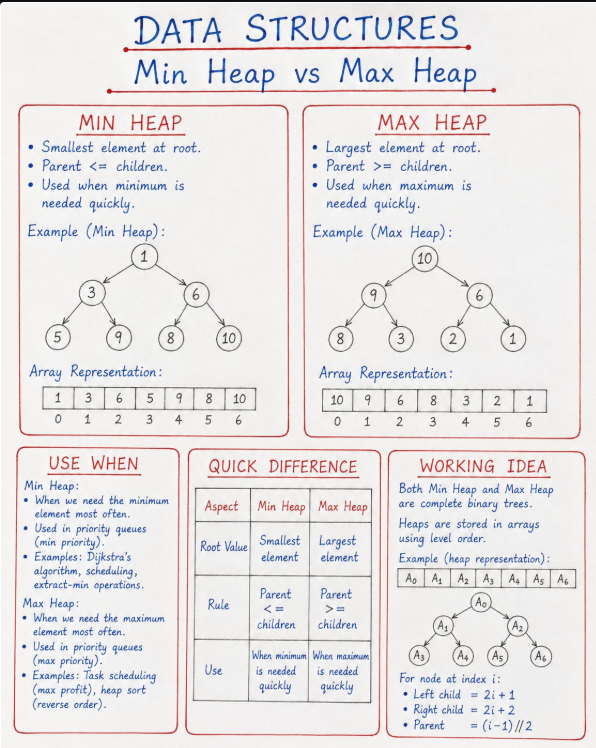

### Min heap implementation in python:

In [5]:
import heapq

### two ways
1. using list
2. creating an empty heap and adding elements

In [8]:
#min-heap
li = [5,3,1,8,10]
heapq.heapify(li)
print(li)

[1, 3, 5, 8, 10]


In [15]:
#max-heap
li = [5,3,1,8,10]
li1 = [-ele for ele in li]
heapq.heapify(li1)
print([-i for i in li1])

[10, 8, 1, 5, 3]


In [17]:
help('heapq')

Help on module heapq:

NAME
    heapq - Heap queue algorithm (a.k.a. priority queue).

MODULE REFERENCE
    https://docs.python.org/3.13/library/heapq.html

    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    Heaps are arrays for which a[k] <= a[2*k+1] and a[k] <= a[2*k+2] for
    all k, counting elements from 0.  For the sake of comparison,
    non-existing elements are considered to be infinite.  The interesting
    property of a heap is that a[0] is always its smallest element.

    Usage:

    heap = []            # creates an empty heap
    heappush(heap, item) # pushes a new item on the heap
    item = heappop(heap) # pops the smallest item from the heap
    item = heap[0]       # smallest item on th

In [19]:
li = [5,3,1,8,10]
heapq.heapify(li)
print(li)
heapq.heappush(li,15)
print(li)
heapq.heappush(li,0)
print(li)

[1, 3, 5, 8, 10]
[1, 3, 5, 8, 10, 15]
[0, 3, 1, 8, 10, 15, 5]


In [20]:
li[0]

0

In [21]:
heapq.heappop(li)

0

In [22]:
heapq.heappop(li)

1

In [23]:
heapq.heappushpop(li,20)

3

In [24]:
li

[5, 8, 20, 15, 10]

In [25]:
heapq.nlargest(2,li)

[20, 15]

In [26]:
heapq.nsmallest(2,li)

[5, 8]

### 215. Kth Largest Element in an Array

In [31]:
from typing import List
class Solution:
    def findKthLargest(self, nums: List[int], k: int) -> int:
        nums.sort(reverse = True)
        return nums[k-1]

obj = Solution()
print(obj.findKthLargest([3,2,1,5,6,4],2))
print(obj.findKthLargest([3,2,3,1,2,4,5,5,6],4))

5
4


In [33]:
from typing import List
import heapq as hp
class Solution:
    def findKthLargest(self, nums: List[int], k: int) -> int:
        hp.heapify(nums)
        return hp.nlargest(k,nums)[k-1]

obj = Solution()
print(obj.findKthLargest([3,2,1,5,6,4],2))
print(obj.findKthLargest([3,2,3,1,2,4,5,5,6],4))

5
4


In [39]:
from typing import List
import heapq as hp
class Solution:
    def findKthLargest(self, nums: List[int], k: int) -> int:
        heap = []
        for ele in nums:
            hp.heappush(heap,ele)
            if len(heap) > k:
                hp.heappop(heap)
        return heap[0]
            
obj = Solution()
print(obj.findKthLargest([3,2,1,5,6,4],2))
print(obj.findKthLargest([3,2,3,1,2,4,5,5,6],4))

5
4


In [34]:
li = [3,2,1,5,6,4]
print(type(li),li)
hp.heapify(li)
print(type(li),li)

<class 'list'> [3, 2, 1, 5, 6, 4]
<class 'list'> [1, 2, 3, 5, 6, 4]


In [35]:
li = [3,2,1,5,6,4]
hp.nlargest(2,li)

[6, 5]

### 347. Top K Frequent Elements

In [44]:
from collections import Counter

class Solution:
    def topKFrequent(self, nums: List[int], k: int) -> List[int]:
        freq = Counter(nums)
        heap = []
        for ele,f in freq.items():
            hp.heappush(heap,(f,ele))
            if len(heap) > k:
                hp.heappop(heap)
            
        return [j for i,j in heap] 

obj = Solution()
print(obj.topKFrequent([1,1,1,2,2,3],2))
print(obj.topKFrequent([1,2,1,2,1,2,3,1,3,2],2))

[2, 1]
[1, 2]


In [43]:
li = [(2, 2), (3, 1)]
for i,j in li:
    print(j)

2
1


### 1046. Last Stone Weight

In [46]:
class Solution:
    def lastStoneWeight(self, stones: List[int]) -> int:
        if len(stones) == 1:
            return stones[0]
        for i in range(len(stones)-1):
            stones.sort(reverse = True)
            stones.append(stones[0] - stones[1])
            del stones[:2]
        return 0 if len(stones) == 0 else stones[0]

obj = Solution()
print(obj.lastStoneWeight([2,7,4,1,8,1]))

1


### Frequently asked questions:
```
1. 703. Kth Largest Element in a Stream
2. 295. Find Median from Data Stream